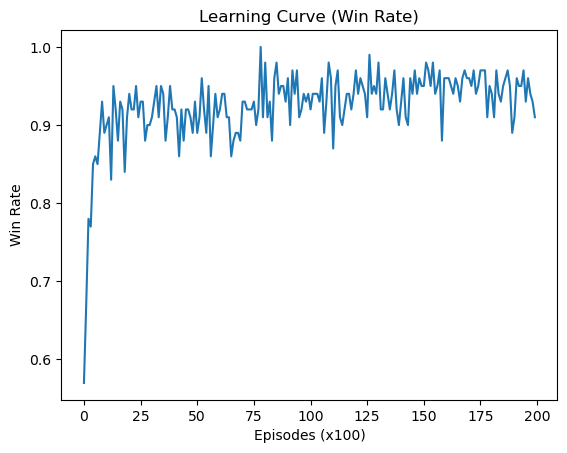

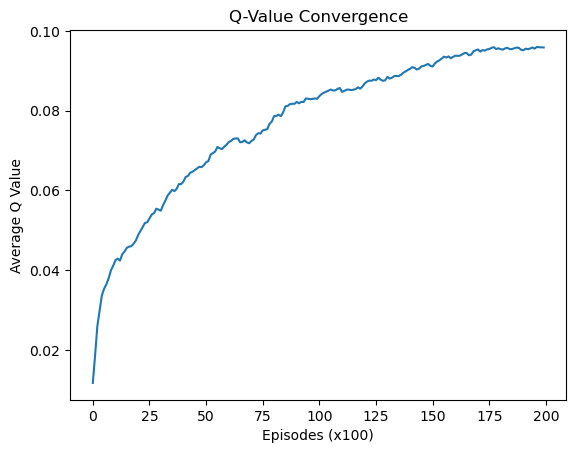

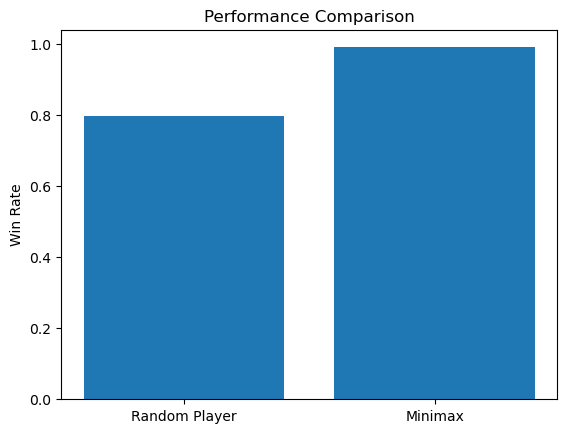

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

Q = {}

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

# ------------------ GAME FUNCTIONS ------------------

def new_board():
    return [' '] * 9

def get_state(board):
    return tuple(board)

def available_moves(board):
    return [i for i in range(9) if board[i] == ' ']

def check_winner(board):
    wins = [(0,1,2),(3,4,5),(6,7,8),
            (0,3,6),(1,4,7),(2,5,8),
            (0,4,8),(2,4,6)]
    for a,b,c in wins:
        if board[a] == board[b] == board[c] != ' ':
            return board[a]
    if ' ' not in board:
        return 'Draw'
    return None

# ------------------ Q-LEARNING ------------------

def choose_action(state, moves):
    if random.uniform(0,1) < epsilon:
        return random.choice(moves)
    q_vals = [Q.get((state,m),0) for m in moves]
    return moves[np.argmax(q_vals)]

def update_q(state, action, reward, next_state, next_moves):
    old = Q.get((state,action),0)
    future = max([Q.get((next_state,m),0) for m in next_moves], default=0)
    Q[(state,action)] = old + alpha*(reward + gamma*future - old)

# ------------------ TRAINING ------------------

def train(episodes=20000):
    global epsilon
    win_rates = []
    q_values_track = []

    wins = 0

    for ep in range(1, episodes+1):
        board = new_board()
        state = get_state(board)

        while True:
            moves = available_moves(board)
            action = choose_action(state, moves)
            board[action] = 'X'

            next_state = get_state(board)
            winner = check_winner(board)

            if winner:
                reward = 1 if winner=='X' else 0 if winner=='Draw' else -1
                if winner=='X': wins += 1
                update_q(state, action, reward, next_state, [])
                break

            # opponent random
            opp = random.choice(available_moves(board))
            board[opp] = 'O'
            winner = check_winner(board)

            if winner:
                reward = -1 if winner=='O' else 0
                update_q(state, action, reward, next_state, [])
                break

            next_moves = available_moves(board)
            update_q(state, action, 0, next_state, next_moves)
            state = next_state

        if epsilon > epsilon_min:
            epsilon *= epsilon_decay

        # Track win rate
        if ep % 100 == 0:
            win_rates.append(wins/100)
            wins = 0

        # Track Q-value magnitude
        if ep % 100 == 0:
            avg_q = np.mean(list(Q.values())) if Q else 0
            q_values_track.append(avg_q)

    return win_rates, q_values_track

# ------------------ RANDOM PLAYER ------------------

def play_random():
    board = new_board()
    while True:
        board[random.choice(available_moves(board))] = 'X'
        if check_winner(board): return check_winner(board)
        board[random.choice(available_moves(board))] = 'O'
        if check_winner(board): return check_winner(board)

# ------------------ MINIMAX ------------------

def minimax(board, is_max):
    winner = check_winner(board)
    if winner == 'X': return 1
    if winner == 'O': return -1
    if winner == 'Draw': return 0

    if is_max:
        best = -999
        for move in available_moves(board):
            board[move] = 'X'
            best = max(best, minimax(board, False))
            board[move] = ' '
        return best
    else:
        best = 999
        for move in available_moves(board):
            board[move] = 'O'
            best = min(best, minimax(board, True))
            board[move] = ' '
        return best

def best_move(board):
    best_val = -999
    move = None
    for m in available_moves(board):
        board[m] = 'X'
        val = minimax(board, False)
        board[m] = ' '
        if val > best_val:
            best_val = val
            move = m
    return move

# ------------------ EVALUATION ------------------

def evaluate_vs_random(games=500):
    wins = 0
    for _ in range(games):
        board = new_board()
        while True:
            state = get_state(board)
            move = choose_action(state, available_moves(board))
            board[move] = 'X'
            if check_winner(board):
                if check_winner(board)=='X': wins += 1
                break

            board[random.choice(available_moves(board))] = 'O'
            if check_winner(board): break
    return wins/games

def evaluate_vs_minimax(games=200):
    wins = 0
    for _ in range(games):
        board = new_board()
        while True:
            state = get_state(board)
            move = choose_action(state, available_moves(board))
            board[move] = 'X'
            if check_winner(board):
                if check_winner(board)=='X': wins += 1
                break

            board[best_move(board)] = 'O'
            if check_winner(board): break
    return wins/games

# ------------------ RUN EVERYTHING ------------------

win_rates, q_values = train(20000)

vs_random = evaluate_vs_random()
vs_minimax = evaluate_vs_minimax()

# ------------------ PLOTS ------------------

# 1️⃣ Learning Curve
plt.figure()
plt.plot(win_rates)
plt.title("Learning Curve (Win Rate)")
plt.xlabel("Episodes (x100)")
plt.ylabel("Win Rate")
plt.show()

# 2️⃣ Q-value Graph
plt.figure()
plt.plot(q_values)
plt.title("Q-Value Convergence")
plt.xlabel("Episodes (x100)")
plt.ylabel("Average Q Value")
plt.show()

# 3️⃣ Comparison Graph
plt.figure()
plt.bar(["Random Player", "Minimax"], [vs_random, vs_minimax])
plt.title("Performance Comparison")
plt.ylabel("Win Rate")
plt.show()

In [8]:
## import random
import numpy as np

# Initialize Q-table
Q = {}

# Hyperparameters
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
epsilon = 1.0    # exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01

# Initialize empty board
def new_board():
    return [' '] * 9

# Convert board to tuple (for dictionary key)
def get_state(board):
    return tuple(board)

# Get available moves
def available_moves(board):
    return [i for i in range(9) if board[i] == ' ']

# Check winner
def check_winner(board):
    wins = [(0,1,2),(3,4,5),(6,7,8),
            (0,3,6),(1,4,7),(2,5,8),
            (0,4,8),(2,4,6)]
    for a,b,c in wins:
        if board[a] == board[b] == board[c] != ' ':
            return board[a]
    if ' ' not in board:
        return 'Draw'
    return None

# Choose action (epsilon-greedy)
def choose_action(state, moves):
    if random.uniform(0,1) < epsilon:
        return random.choice(moves)
    else:
        q_values = [Q.get((state, m), 0) for m in moves]
        return moves[np.argmax(q_values)]

# Update Q-value
def update_q(state, action, reward, next_state, next_moves):
    old_q = Q.get((state, action), 0)
    future_q = 0
    if next_moves:
        future_q = max([Q.get((next_state, m), 0) for m in next_moves])
    
    Q[(state, action)] = old_q + alpha * (reward + gamma * future_q - old_q)

# Train agent
def train(episodes=50000):
    global epsilon
    for _ in range(episodes):
        board = new_board()
        state = get_state(board)
        
        while True:
            moves = available_moves(board)
            action = choose_action(state, moves)
            
            board[action] = 'X'
            next_state = get_state(board)
            winner = check_winner(board)
            
            if winner:
                if winner == 'X':
                    reward = 1
                elif winner == 'Draw':
                    reward = 0
                else:
                    reward = -1
                
                update_q(state, action, reward, next_state, [])
                break
            
            # Opponent plays randomly
            opp_move = random.choice(available_moves(board))
            board[opp_move] = 'O'
            winner = check_winner(board)
            
            if winner:
                if winner == 'O':
                    reward = -1
                elif winner == 'Draw':
                    reward = 0
                else:
                    reward = 1
                
                update_q(state, action, reward, next_state, [])
                break
            
            next_moves = available_moves(board)
            update_q(state, action, 0, next_state, next_moves)
            state = next_state
        
        # Reduce exploration
        if epsilon > epsilon_min:
            epsilon *= epsilon_decay

# Play game with trained agent
def play():
    board = new_board()
    
    while True:
        print_board(board)
        
        # Agent move
        state = get_state(board)
        move = choose_action(state, available_moves(board))
        board[move] = 'X'
        
        if check_winner(board):
            print_board(board)
            print("Agent wins!" if check_winner(board) == 'X' else "Draw!")
            break
        
        # Human move
        human = int(input("Enter position (0-8): "))
        if board[human] == ' ':
            board[human] = 'O'
        else:
            print("Invalid move!")
            continue
        
        if check_winner(board):
            print_board(board)
            print("You win!" if check_winner(board) == 'O' else "Draw!")
            break

# Print board
def print_board(board):
    for i in range(0, 9, 3):
        print(board[i:i+3])
    print()

# Run training
train(50000)

# Play game
play()

[' ', ' ', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']



Enter position (0-8):  1


['X', 'O', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']



Enter position (0-8):  5


['X', 'O', 'X']
[' ', ' ', 'O']
[' ', ' ', ' ']



Enter position (0-8):  4


['X', 'O', 'X']
['X', 'O', 'O']
[' ', ' ', ' ']

['X', 'O', 'X']
['X', 'O', 'O']
['X', ' ', ' ']

Agent wins!


Initial Q-table: {}
Episode 10000 completed
Episode 20000 completed
Episode 30000 completed
Episode 40000 completed
Episode 50000 completed

Final Q-table size: 1658

Sample Q-table entries after training:

State: (' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ')
Action: 3
Q-value: 0.09874836877397954
----------------------
State: (' ', ' ', ' ', 'X', ' ', ' ', ' ', ' ', ' ')
Action: 5
Q-value: 0.0
----------------------
State: (' ', ' ', ' ', 'X', ' ', 'X', ' ', ' ', 'O')
Action: 2
Q-value: 0.0
----------------------
State: (' ', 'O', 'X', 'X', ' ', 'X', ' ', ' ', 'O')
Action: 4
Q-value: 0.1
----------------------
State: (' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ')
Action: 1
Q-value: 0.07745221987711243
----------------------
State: (' ', 'X', ' ', ' ', ' ', ' ', ' ', ' ', ' ')
Action: 6
Q-value: 0.0
----------------------
State: (' ', 'X', 'O', ' ', ' ', ' ', 'X', ' ', ' ')
Action: 3
Q-value: 0.0
----------------------
State: ('O', 'X', 'O', 'X', ' ', ' ', 'X', ' ', ' ')
Action: 5
Q-val

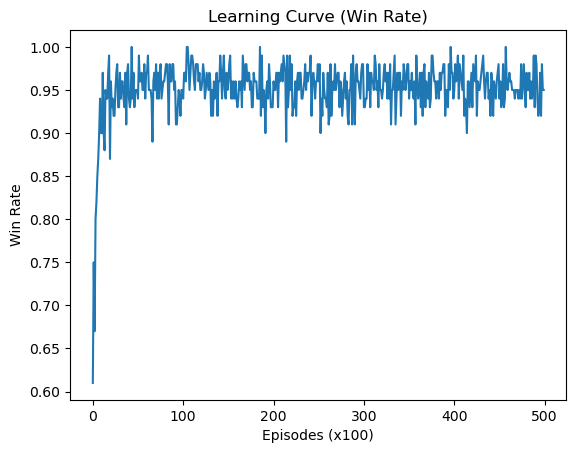

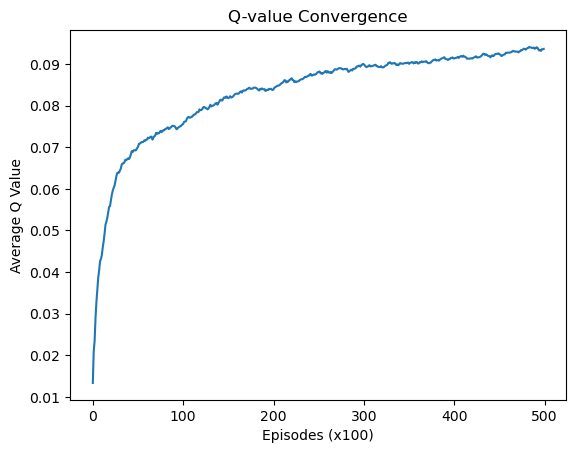

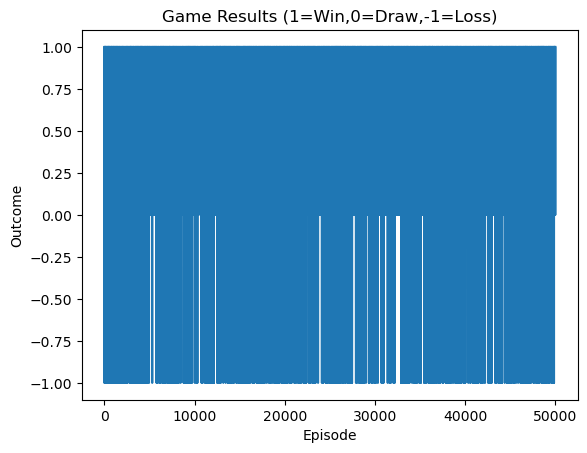

[' ', ' ', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ']



Enter position (0-8):  3


[' ', ' ', ' ']
['O', 'X', ' ']
[' ', ' ', ' ']



Enter position (0-8):  0


['O', ' ', 'X']
['O', 'X', ' ']
[' ', ' ', ' ']



In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# ---------------- PARAMETERS ----------------
Q = {}
initial_Q_snapshot = {}

alpha = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

# ---------------- GAME FUNCTIONS ----------------
def new_board():
    return [' '] * 9

def get_state(board):
    return tuple(board)

def available_moves(board):
    return [i for i in range(9) if board[i] == ' ']

def check_winner(board):
    wins = [(0,1,2),(3,4,5),(6,7,8),
            (0,3,6),(1,4,7),(2,5,8),
            (0,4,8),(2,4,6)]
    
    for a,b,c in wins:
        if board[a] == board[b] == board[c] != ' ':
            return board[a]
    
    if ' ' not in board:
        return 'Draw'
    
    return None

# ---------------- Q-LEARNING ----------------
def choose_action(state, moves, eps):
    if random.uniform(0,1) < eps:
        return random.choice(moves)
    
    q_vals = [Q.get((state,m), 0) for m in moves]
    max_q = max(q_vals)
    
    best = [moves[i] for i in range(len(moves)) if q_vals[i] == max_q]
    return random.choice(best)

def update_q(state, action, reward, next_state, next_moves):
    old = Q.get((state, action), 0)
    future = max([Q.get((next_state,m),0) for m in next_moves], default=0)
    
    Q[(state, action)] = old + alpha*(reward + gamma*future - old)

# ---------------- TRAINING ----------------
def train(episodes=50000):
    global epsilon
    win_rates = []
    q_history = []
    game_results = []
    
    wins = 0
    
    print("Initial Q-table:", Q)  # should be empty
    
    for ep in range(1, episodes+1):
        board = new_board()
        state = get_state(board)
        
        while True:
            moves = available_moves(board)
            action = choose_action(state, moves, epsilon)
            board[action] = 'X'
            
            next_state = get_state(board)
            winner = check_winner(board)
            
            if winner:
                if winner == 'X':
                    reward = 1
                    wins += 1
                    game_results.append(1)
                elif winner == 'Draw':
                    reward = 0
                    game_results.append(0)
                else:
                    reward = -1
                    game_results.append(-1)
                
                update_q(state, action, reward, next_state, [])
                break
            
            # Opponent (random)
            opp_moves = available_moves(board)
            if opp_moves:
                opp = random.choice(opp_moves)
                board[opp] = 'O'
            
            winner = check_winner(board)
            
            if winner:
                if winner == 'O':
                    reward = -1
                    game_results.append(-1)
                elif winner == 'Draw':
                    reward = 0
                    game_results.append(0)
                else:
                    reward = 1
                    game_results.append(1)
                
                update_q(state, action, reward, next_state, [])
                break
            
            next_moves = available_moves(board)
            update_q(state, action, 0, next_state, next_moves)
            state = next_state
        
        # decay epsilon
        if epsilon > epsilon_min:
            epsilon *= epsilon_decay
        
        # tracking
        if ep % 100 == 0:
            win_rates.append(wins / 100)
            wins = 0
            
            avg_q = np.mean(list(Q.values())) if Q else 0
            q_history.append(avg_q)
        
        if ep % 10000 == 0:
            print(f"Episode {ep} completed")
    
    print("\nFinal Q-table size:", len(Q))
    
    return win_rates, q_history, game_results

# ---------------- RUN TRAINING ----------------
win_rates, q_history, game_results = train(50000)

# ---------------- SHOW Q-TABLE SAMPLE ----------------
print("\nSample Q-table entries after training:\n")

for i, ((state, action), value) in enumerate(Q.items()):
    print("State:", state)
    print("Action:", action)
    print("Q-value:", value)
    print("----------------------")
    if i == 10:
        break

# ---------------- GRAPHS ----------------
plt.figure()
plt.plot(win_rates)
plt.title("Learning Curve (Win Rate)")
plt.xlabel("Episodes (x100)")
plt.ylabel("Win Rate")
plt.show()

plt.figure()
plt.plot(q_history)
plt.title("Q-value Convergence")
plt.xlabel("Episodes (x100)")
plt.ylabel("Average Q Value")
plt.show()

plt.figure()
plt.plot(game_results)
plt.title("Game Results (1=Win,0=Draw,-1=Loss)")
plt.xlabel("Episode")
plt.ylabel("Outcome")
plt.show()

# ---------------- PLAY WITH AI ----------------
def play():
    board = new_board()
    
    while True:
        print(board[0:3])
        print(board[3:6])
        print(board[6:9])
        print()
        
        # AI move
        state = get_state(board)
        move = choose_action(state, available_moves(board), 0)
        board[move] = 'X'
        
        if check_winner(board):
            print("AI wins!" if check_winner(board)=='X' else "Draw!")
            break
        
        # Human move
        human = int(input("Enter position (0-8): "))
        
        if board[human] != ' ':
            print("Invalid move!")
            continue
        
        board[human] = 'O'
        
        if check_winner(board):
            print("You win!" if check_winner(board)=='O' else "Draw!")
            break

# Uncomment to play
play()